# TASK 1. PROJECT OVERVIEW AND KEY LEARNING OBJECTIVES

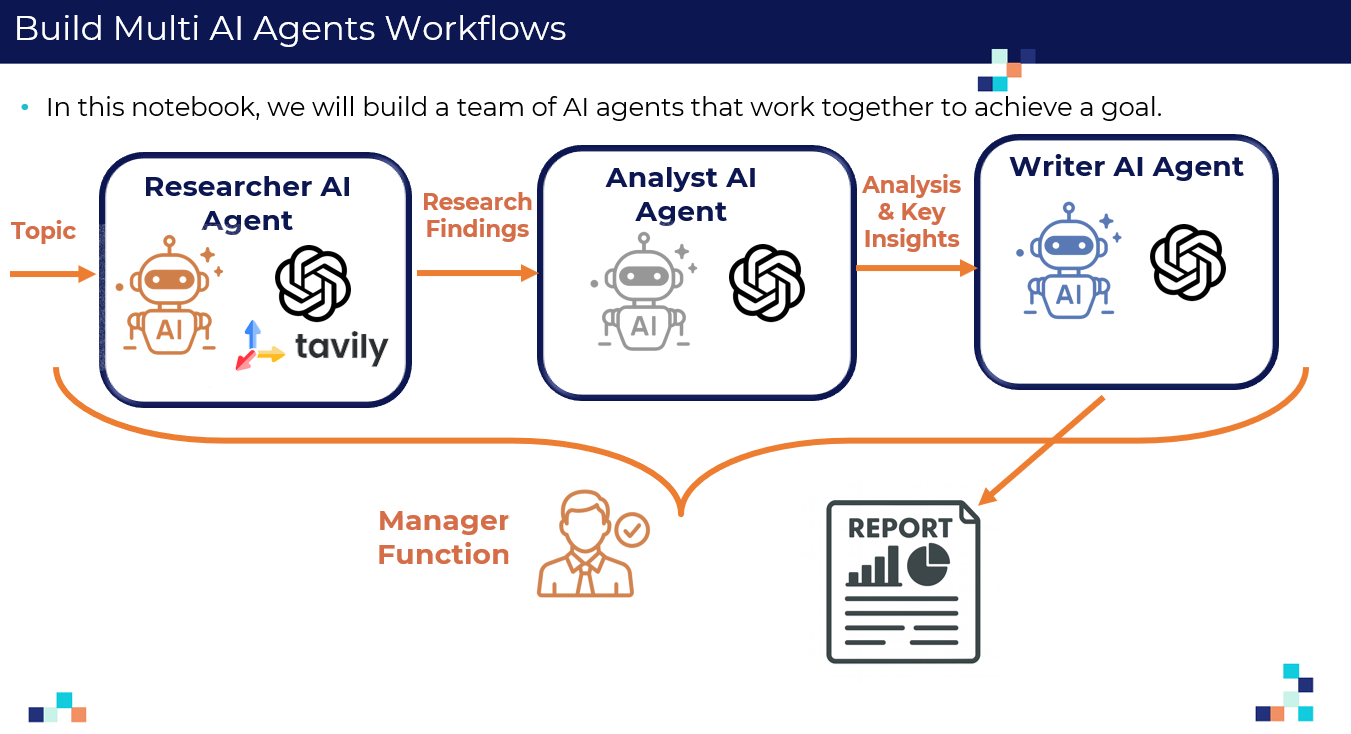

# TASK 2. SETUP API KEYS & DEFINE REQUIRED TOOLS

In [1]:
!pip install -q openai-agents==0.2.2 python-dotenv requests pydantic

In [2]:
import os
import requests
from IPython.display import display, Markdown
from openai import OpenAI
from dotenv import load_dotenv
from agents import Agent, Runner, function_tool, SQLiteSession
from typing_extensions import TypedDict
from pydantic import BaseModel

load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

print("✅ API keys loaded")
print(f"  OpenAI … {openai_api_key[:5]}***")
print(f"  Tavily … {tavily_api_key[:5]}***")


✅ API keys loaded
  OpenAI … sk-pr***
  Tavily … tvly-***


In [3]:
def print_markdown(text):
    display(Markdown(text))

In [4]:
# A TypedDict describes the expected keys and value types for a dict.
# Here: a search "query" (string) and "max_results" (int).

class TavilySearchParams(TypedDict):
    query: str
    max_results: int


# This decorator (from OpenAI Agents SDK) registers the function as a tool
# that an agent can call. 

@function_tool
def tavily_search(params: TavilySearchParams) -> str:

    # Tavily search endpoint
    url = "https://api.tavily.com/search"

    # Tell the API we're sending JSON
    headers = {"Content-Type": "application/json"}

    # Build the request body:
    # api_key: your Tavily API key (assumed defined elsewhere as tavily_api_key)
    # query: taken from the params dict
    # max_results: use provided value or default to 3 if missing
    payload = {
        "api_key": tavily_api_key,
        "query": params["query"],
        "max_results": params.get("max_results", 3),
    }

    # Send the POST request with JSON body and headers
    response = requests.post(url, json = payload, headers = headers)
    if response.status_code == 200:
        results = response.json().get("results", [])
        summary = "\n".join([f"- {r['title']}: {r['content']}" for r in results])
        return summary if summary else "No relevant results found."
    else:
        return f"Tavily API error: {response.status_code}"

print("✅ Tavily search tool ready.")

✅ Tavily search tool ready.


# TASK 3. DEFINE TWO AI AGENTS (RESEARCHER & ANALYST)

In [5]:
# Let's define our Researcher AI Agent

# Define a Pydantic model for the agent's output.
# This ensures the agent's final output will have a single field: "summary" (string).
# Note that this will be used in both the researcher and analyst agents
class AnalysisSummary(BaseModel):
    summary: str


# Create an AI agent called "Researcher"
researcher_agent = Agent(name = "Researcher",
                         instructions = """
## Context
You are a research agent with access to the Tavily search tool.

## Instruction
Given a user query, use the Tavily search tool to find relevant information and summarize the key findings.

## Input
- A research query from the user.

## Output
- A summary of key findings in a maximum of 5 bullet points.
""",
    model = "gpt-4.1-mini",
    tools = [tavily_search],
    output_type = AnalysisSummary)

print("✅ Researcher AI agent is now ready")

✅ Researcher AI agent is now ready


In [6]:
# Let's run the researcher AI agent
researcher_result = await Runner.run(researcher_agent, "Why is Labubu so popular and what are the rarest Labubu collectibles?")
researcher_result

RunResult(input='Why is Labubu so popular and what are the rarest Labubu collectibles?', new_items=[ToolCallItem(agent=Agent(name='Researcher', handoff_description=None, tools=[FunctionTool(name='tavily_search', description='', params_json_schema={'$defs': {'TavilySearchParams': {'properties': {'query': {'title': 'Query', 'type': 'string'}, 'max_results': {'title': 'Max Results', 'type': 'integer'}}, 'required': ['query', 'max_results'], 'title': 'TavilySearchParams', 'type': 'object', 'additionalProperties': False}}, 'properties': {'params': {'$ref': '#/$defs/TavilySearchParams'}}, 'required': ['params'], 'title': 'tavily_search_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x000002B06C4BD580>, strict_json_schema=True, is_enabled=True)], mcp_servers=[], mcp_config={}, instructions='\n## Context\nYou are a research agent with access to the Tavily search tool.\n\n## Instruction\n

In [7]:
print_markdown(f"### 🤖 Agent’s Answer\n{researcher_result.final_output.summary}")

### 🤖 Agent’s Answer
- Labubu dolls are popular due to their cute charm and status as collectibles that are hard to obtain, creating excitement among fans.
- The figures are often rare because of limited releases, secret editions, and blind box surprises.
- Each Labubu release typically includes 12 regular designs plus a much rarer secret design that appeals to collectors.
- The popularity of Labubu is boosted by clever celebrity endorsements, blind box marketing strategies, and reselling by scalpers.
- The character Labubu was created by Chinese artist Kasing Lung and produced by Pop Mart, a well-known company in the designer toy industry.

In [8]:
# Let's define our Analyst AI Agent

analyst_agent = Agent(name = "Analyst",
                      instructions = """
## Context
You are an analyst who receives research notes generated by the research agent.

## Instruction
Given the research notes, analyze the content and extract key trends, risks, or insights.

## Input
- Research notes (summaries of findings from the research agent).

## Output
- A concise analysis (no more than 2 paragraphs) highlighting key trends, risks, or insights.
""",
    model = "gpt-4.1-mini",
    output_type = AnalysisSummary,
)

print("✅ Analyst AI agent us now ready")

✅ Analyst AI agent us now ready


**PRACTICE OPPORTUNITY:**  

- **Use the `researcher_agent` and `analyst_agent` to analyze a specific research question or topic.**

  - **Provide a research question (e.g., "What are the latest trends in Batteries for Electric Vehicles?").**
  - **Call the `researcher_agent` with the research question to obtain key findings.**
  - **Pass the researcher's summary to the `analyst_agent` to extract key trends, risks, or insights.**
  - **Show how you would structure the conversation and pass information between the agents.**


# TASK 4: DEFINE A WRITER AI AGENT (EXECUTIVE REPORT GENERATOR)

In [14]:
# Define a Pydantic model for the agent's output
# This specifies exactly what fields the Writer agent should return

class FinalReport(BaseModel):
    short_summary: str  # A brief 2–3 sentence executive summary
    markdown_report: str    # A detailed report in Markdown format (at least 500 words)
    follow_up_questions: list[str]    # A list of 3–5 suggested follow-up research questions


# Create an AI agent called "Writer"
writer_agent = Agent(
    name = "Writer",
    instructions = """
You are a senior market analyst tasked with generating an executive-level research report.

## Context
You will receive:
- The original user query (the research question or topic of interest).
- Summaries and analyses generated by helper tools: 'researcher_agent' (for bullet-point research findings) and 'analyst_agent' (for key trends, risks, or insights).

You may call these helper tools as needed to gather additional information or clarify findings.

## Instructions
Your job is to synthesize all available information and produce the following outputs:
1. **Executive Summary:** Write a concise summary (2–3 sentences) highlighting the most important findings relevant to the original query.
2. **Detailed Markdown Report:** Compose a comprehensive, well-structured report in markdown format (at least 500 words) that covers key findings, context, implications, and supporting evidence.
3. **Follow-up Research Questions:** Suggest 3–5 thoughtful follow-up questions for further investigation.

## Input
- The original user query.
- Summaries and analyses from the helper tools.

## Output
Return a structured object with:
- `short_summary`: The executive summary.
- `markdown_report`: The detailed markdown report.
- `follow_up_questions`: A list of 3–5 follow-up research questions.
""",
    model = "gpt-4.1-mini",
    output_type = FinalReport,
)

print("✅ Writer AI Agent is now ready")

✅ Writer AI Agent is now ready


**PRACTICE OPPORTUNITY:**
- **Rewrite the `writer` agent’s instructions so that it generates all outputs entirely in French (Executive Summary, Detailed Markdown Report, and Follow-up Research Questions).**
- **Note: We will test this AI Agent in the next task so stay tuned!**

## TASK 5. BUILD A MANAGER FUNCTION TO ORCHESTRATE THE FULL PIPELINE)

In [18]:
# Create a session to store and share information between agents
session = SQLiteSession("research_agent_practice")

# Define an async function that takes the user's question and runs the agents
async def manager_run(user_query: str):
    # Show the user’s question in a nice markdown format
    print_markdown(f"**User's Request:** {user_query}")

    # Step 1: Run the researcher agent to gather information about the user's query
    researcher_result = await Runner.run(researcher_agent, user_query, session = session)
    research_summary = researcher_result.final_output.summary  # Get the short research summary

    # Step 2: Run the analyst agent to analyze the research findings
    analyst_result = await Runner.run(analyst_agent, research_summary, session = session)
    analysis_summary = analyst_result.final_output.summary  # Get the short analysis summary

    # Step 3: Prepare the combined input for the writer agent
    input_for_writer = (
        f"Original query: {user_query}\n"
        f"Research summary: {research_summary}\n"
        f"Analysis summary: {analysis_summary}"
    )

    # Step 4: Run the writer agent to create the final report
    writer_result = await Runner.run(writer_agent, input_for_writer, session = session)
    final_output: FinalReport = writer_result.final_output  # The final report from the writer

    # Step 5: Display the results in a nice, clear format
    print_markdown("---")
    print_markdown(f"### 📝 **Short Summary:**\n{final_output.short_summary}")  # Quick overview
    print_markdown("\n\n-----------------\n\n")
    print_markdown(f"### 📄 **Full Report (Markdown):**\n{final_output.markdown_report}")  # Detailed report
    print_markdown("\n\n-----------------\n\n")
    print_markdown(
        "### 🔍 **Follow-Up Questions:**\n- "
        + "\n- ".join(final_output.follow_up_questions)  # Any extra questions the user might explore
    )
    print_markdown("\n\n-----------------\n\n")

In [19]:
await manager_run("What is the public sentiment and expert reviews about the Tesla Cybertruck?")

**User's Request:** What is the public sentiment and expert reviews about the Tesla Cybertruck?

---

### 📝 **Short Summary:**
Le Tesla Cybertruck est largement apprécié par ses propriétaires pour sa technologie avancée, son intérieur spacieux et silencieux, ses performances rapides et sa maniabilité exceptionnelle, en faisant un des meilleurs pick-ups pour un usage quotidien. Bien que certains experts reconnaissent quelques défauts, ils soulignent son innovation et son design unique, tandis que les retours des utilisateurs sur le long terme confirment sa durabilité et un entretien raisonnable. Malgré un certain scepticisme public, l'attrait novateur du Cybertruck maintient une réputation positive solide.



-----------------



### 📄 **Full Report (Markdown):**
# Rapport sur la perception publique et les avis d'experts concernant le Tesla Cybertruck

## Introduction
Le Tesla Cybertruck, lancé avec un style futuriste et une technologie de pointe, suscite depuis son annonce un large éventail de réactions tant du grand public que des spécialistes de l'automobile. Ce rapport synthétise les sentiments exprimés par les propriétaires, les avis des experts, et les tendances observées sur le long terme.

## Sentiment des propriétaires
Les propriétaires de Cybertruck témoignent majoritairement d'une satisfaction élevée. Ils mettent en avant plusieurs atouts clés :

- **Technologie avancée** : Intégration des systèmes de conduite autonome (FSD), commandes digitales avancées.
- **Confort intérieur** : Un habitacle spacieux, silencieux, et ergonomique.
- **Performances** : Rapidité, tenue de route stable avec un comportement dynamique comparable à celui d'une voiture compacte.
- **Facilité d'utilisation** : Maniabilité en ville, facilité de stationnement et autonomie appréciable.

Ces éléments font du Cybertruck un véhicule très apprécié pour un usage quotidien, surpassant souvent les attentes classiques des pick-ups traditionnels.

## Avis des experts
Les experts reconnaissent certains défauts inhérents au design angulaire et au style non conventionnel du Cybertruck, ce qui peut diviser l'opinion publique. Cependant, ils s'accordent généralement sur les points suivants :

- **Innovation** : Le véhicule repousse les limites du concept de pick-up grâce à une structure en acier inoxydable et une motorisation entièrement électrique.
- **Performance technique** : La puissance, l'autonomie et les fonctionnalités intelligentes sont jugées avancées pour le segment.
- **Impact sur le marché** : Le Cybertruck stimule la concurrence et suscite un renouvellement du secteur des véhicules utilitaires.

Ces analyses renforcent l'image d'un véhicule innovant malgré quelques critiques concernant son esthétique ou certaines fonctionnalités.

## Retours à long terme
Les utilisateurs qui possèdent le Cybertruck depuis plus d'un an rapportent une expérience globalement positive, notamment :

- **Durabilité** : Le véhicule conserve ses performances sans usure excessive.
- **Entretien** : Les coûts restent raisonnables et les pannes sont rares.
- **Satisfaction générale** : L'enthousiasme initial ne faiblit pas, avec un maintien d'une forte confiance dans le produit.

Cela confirme la fiabilité du Cybertruck au-delà de la phase de nouveauté.

## Perception publique
Malgré l'émerveillement de nombreux propriétaires, une partie du public demeure sceptique, notamment en raison de :

- Son design atypique qui divise.
- La méfiance envers le constructeur Tesla et sa communication.
- L'incertitude liée à la production et à la disponibilité commerciale.

Cependant, ces réticences n'affaiblissent pas la popularité et la reconnaissance du Cybertruck comme un véhicule emblématique.

## Conclusion
Le Tesla Cybertruck s'impose comme un modèle novateur et apprécié, tant par ses utilisateurs que par des experts qui reconnaissent son caractère avant-gardiste malgré quelques critiques. Sa durabilité et son attractivité devraient lui assurer une place importante sur le marché des pick-ups électriques dans les années à venir.



-----------------



### 🔍 **Follow-Up Questions:**
- Quels sont les principaux défauts techniques identifiés par les experts sur le Tesla Cybertruck ?
- Comment le Cybertruck se compare-t-il aux pick-ups électriques concurrents sur le marché en termes de performances et d'autonomie ?
- Quelle est la perception du Tesla Cybertruck dans les différents marchés internationaux, notamment en Europe et en Asie ?
- Quels sont les impacts environnementaux réels du Cybertruck comparés aux pick-ups traditionnels à essence ou diesel ?
- Quel est le niveau de satisfaction des utilisateurs concernant les services après-vente et le support Tesla pour le Cybertruck ?



-----------------



**PRACTICE OPPORTUNITY:**
- **Run the pipeline again using the `writer` agent with French language report generation capability (from the previous practice opportunity).**

- **Create a new multi-agent team that performs creative advertising:**
  - **Define a `Creative_Director` agent that brainstorms 3–5 ad ideas.**
  - **Define a `Strategist` agent that selects the top 2 ideas and explains the reasoning.**
  - **Define a `Copywriter` agent that writes tweets for each top campaign.**
  - **Set up any necessary tools for these agents.**
  - **Build a pipeline where the output of each agent is passed to the next, similar to the previous example.**
  - **Try running the full pipeline on a sample prompt (e.g., "Launch campaign for a new eco-friendly water bottle in Bali").**